<a href="https://colab.research.google.com/github/tanviupadhyay1517/Hypothesis-Testing-/blob/main/Indep_t_test_Product_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study
A product manager wants to determine if Product X has significantly higher average monthly sales compared to Product Y. This analysis helps decide if Product X should receive more investment for scaling up production and marketing. [Data: product_sales.xlsx]

# Import necessary packages

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Mounting Google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Read data

In [3]:
# Reading the data

df = pd.read_excel('/content/drive/MyDrive/Classroom/FTN Batch 10/T test Two sample/product_sales.xlsx')

# Exploratory Analysis

In [4]:
df.columns

Index(['Month', 'Product', 'Monthly_Sales'], dtype='object')

In [5]:
df.head()                                   # Viewing first few observations of the data

,Month,Product,Monthly_Sales
0,1,X,479.231463
1,2,X,528.967734
2,3,X,532.864274
3,4,X,509.886137
4,5,X,541.935714


In [6]:
df.describe()                               # Descriptive statistics

,Month,Monthly_Sales
count,24.000000,24.000000
mean,6.500000,526.597818
std,3.526299,52.776767
min,1.000000,429.907447
25%,3.750000,496.293797
50%,6.500000,535.230463
75%,9.250000,557.538078
max,12.000000,644.309295


<Axes: title={'center': 'Monthly_Sales'}, xlabel='Product'>

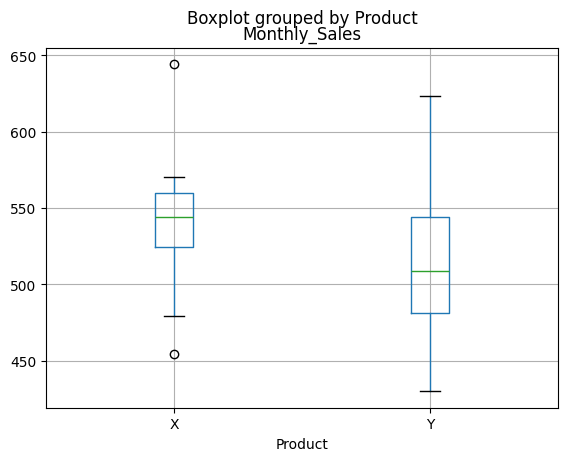

In [7]:
df.boxplot(by ='Product', column =['Monthly_Sales'])  # Box-plot

# Normality test using Shapiro test

In [10]:
Shapiro1 = stats.shapiro(df.Monthly_Sales[df.Product == 'X'])
print("Shapiro-Wilk test for Product X:", Shapiro1)

Shapiro-Wilk test for Product X: ShapiroResult(statistic=np.float64(0.9403875621490173), pvalue=np.float64(0.5031092104414205))


In [11]:
Shapiro2 = stats.shapiro(df.Monthly_Sales[df.Product == 'Y'])
print("Shapiro-Wilk test for Product Y:", Shapiro2)

Shapiro-Wilk test for Product Y: ShapiroResult(statistic=np.float64(0.9742130510517012), pvalue=np.float64(0.9495578846986631))


# Normality check using Q-Q plot

In [12]:
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot

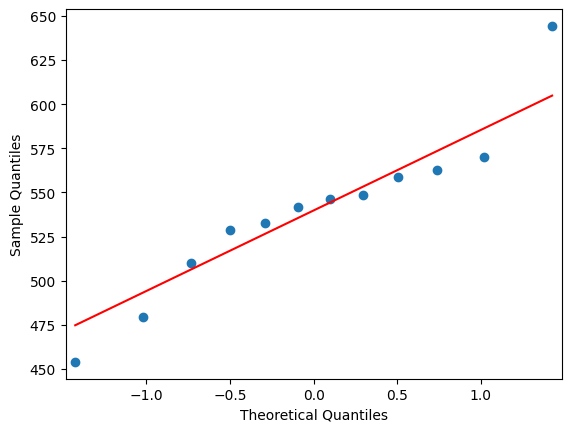

In [15]:
qqplot(df[df['Product'] == 'X']['Monthly_Sales'], line='s')
plt.show()

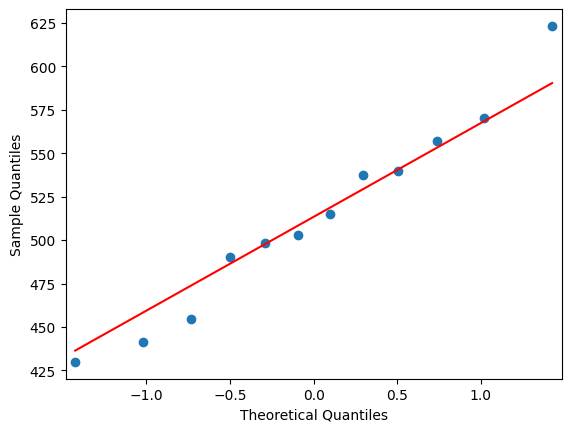

In [16]:
qqplot(df[df['Product'] == 'Y']['Monthly_Sales'], line='s')
plt.show()


## Testing Equality of Variances

In [17]:
# Levene test using Center as Mean
stats.levene(df.Monthly_Sales[df.Product == 'X'],df.Monthly_Sales[df.Product == 'Y'],center='mean')

LeveneResult(statistic=np.float64(0.704062528289113), pvalue=np.float64(0.4104472689189018))

# Independent t test

In [18]:
res = stats.ttest_ind(df.Monthly_Sales[df.Product == 'X'],df.Monthly_Sales[df.Product == 'Y'],equal_var=True,
  alternative='greater')
res

TtestResult(statistic=np.float64(1.2431990140203477), pvalue=np.float64(0.1134404171277926), df=np.float64(22.0))

In [19]:
print("Average performance of INDIA Country:",(df.Monthly_Sales[df.Product == 'X']).mean())
print("Average performance of USA Country:",(df.Monthly_Sales[df.Product == 'Y']).mean())

Average performance of INDIA Country: 539.8347516368128
Average performance of USA Country: 513.3608853343663
